In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools

import taurex
import xarray as xr
import os
import pandas as pd
import astropy

from taurex.cache import OpacityCache, CIACache
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel
from taurex.pressure import SimplePressureProfile

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from taurex.binning import FluxBinner



Numba not installed, using numpy instead


In [3]:
# planet directory


planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44]
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days

star_temperature = [5261,4570,3381,4850,4440,5342,4884,4914] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr

# columns in the csv file
#pressure = 0
#terminator = 1
#substellar = 2
#average = 3

In [3]:
# binned points
terminator = False; new = True

new_point1 = (0.95,0.3,1.156,0.112)
new_point2 = (1.549, 0.151, 1.708, 0.166)

new_point3 = (2.356, 0.0468, 2.403,0.0478)
new_point4 = (2.451, 0.0487, 2.500,0.0497)

new_point5 = (2.762,0.0549, 2.818, 0.056)
new_point6 = (2.875,0.057, 2.932, 0.058)

new_point7 = (3.439, 0.068, 3.507, 0.0690)
new_point8 = (3.578, 0.071, 3.65, 0.072)

new_point9 = (3.723, 0.074, 4.032, 0.264)
new_point10 = (4.30, 0.282, 4.597, 0.301)

new_point11 = (5.597,0.367, 5.976, 0.391)
new_point12 = (6.38, 0.418, 6.814, 0.447)

In [12]:
def save_eclipse(name, transits, plot):

    """
    Function which takes as input the name of the planet directory
    and saves the binned emission spectrum in ARIEL wavelength with expected observation
    as a pdf file.
    """

    outputdir = f"PLANETS/{name}/"
    planetdir = f"PLANETS/{name}/{name}_TP.csv"
    base_name = name.split("_", 1)[0]

    temp_profile = TemperatureFile(planetdir, skiprows=1, 
                               temp_col=2, press_col=0, 
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    #read-in the atmospheric composition
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    #for lHS1478
    mass = planet_masses[planet_names.index(base_name)] #Earth masses
    #convert to jupiter masses
    mass = mass / 317.8
    #semi-major axis
    a = planet_distances[planet_names.index(base_name)] #AU

    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_distance=a)

    #for now use a blackbody star
    #star = BlackbodyStar(temperature=star_temperature[planet_names.index(name)], radius=star_radius[planet_names.index(name)])

    #to be implemented
    star = PhoenixStar(temperature=star_temperature[int(planet_names.index(base_name))], radius=star_radius[int(planet_names.index(base_name))], metallicity=star_metallicity[int(planet_names.index(base_name))], phoenix_path='phoenix/')

    em = EmissionModel(
    planet=planet,
    temperature_profile=temp_profile,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em.add_contribution(AbsorptionContribution())
    em.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em.add_contribution(RayleighContribution())

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em_terminator.add_contribution(RayleighContribution())

    em.build()
    em_terminator.build()

    wngrid, fpfs, tau, _ = em.model()
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid = 10000/wngrid[::-1]; wlgrid_t = 10000/wngrid_t[::-1]
    fpfs = fpfs[::-1]; fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    if os.path.exists(f"ARIEL/arielrad_{base_name}/tier2.csv"):
        file = f"ARIEL/arielrad_{base_name}/tier2.csv"
    else:
        print(f"Ariel noise model file not found for {base_name}.")
        return 

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

    #instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output = fb.bindown(wlgrid, fpfs)
    output_t = fb.bindown(wlgrid_t, fpfs_t)

    N = transits #number of observed transits

    plt.figure(figsize=(8,6))
    plt.plot(wlgrid, fpfs, color='black')
    #plt.errorbar(output[0], np.random.normal(output[1],noise/np.sqrt(10)), yerr=noise/np.sqrt(10), fmt='o')
    plt.errorbar(output[0], output[1], yerr=noise/np.sqrt(N), capsize=5, fmt='o', color='red', alpha=0.8)

    yerr = noise / np.sqrt(N)

    # set appropriate y-limits based on the singular plot
    y_all = np.concatenate([
        output[1] + yerr,
        output[1] - yerr,
        output_t[1] + yerr,
        output_t[1] - yerr,
    ])

    ymin = y_all.min()
    ymax = y_all.max()

    pad = 0.0001 * (ymax - ymin)
    plt.ylim(ymin - pad, ymax + pad)

    time = float(planet_period[planet_names.index(base_name)]) * N * 24 #in hours

    plt.xlabel("Wavelength (um)")
    plt.ylabel("$(F_p/F_s)$")
    #plt.xscale("log")
    plt.xlim(0.3, 9)
    plt.title(f"{name} - Substellar Profile- {time:.2f} hours")
    plt.tight_layout()
    plt.savefig(f"PLANETS/{name}/emission_spectrum_{N}.pdf", format='pdf')
    if plot:
        show()
    close()

    plt.figure(figsize=(8,6))
    plt.plot(wlgrid_t, fpfs_t, color='black')
    #plt.errorbar(output_t[0], np.random.normal(output_t[1],noise/np.sqrt(N)), yerr=noise/np.sqrt(10), fmt='o')
    plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(N), capsize=5, fmt='o', color='red', alpha=0.8)
    plt.xlabel("Wavelength (um)")
    plt.ylabel("$(F_p/F_s)$")
    #plt.xscale("log")
    plt.xlim(0.3, 9)
    plt.title(f"{name} - Terminator Profile - {time:.2f} hours")
    plt.tight_layout()
    plt.savefig(f"PLANETS/{name}/emission_spectrum_terminator_{N}.pdf", format='pdf')
    if plot:
        show()
    close()

    return output, noise, wlgrid, fpfs, output_t, wlgrid_t, fpfs_t

def bindown_single(w1, d1, w2, d2, output, noise, transits):
    wf = (w1 + w2) / 2
    df = (w2 + d2/2) - (w1 - d1/2)

    photogrid = np.array([[wf], [df]])

    fb2 = FluxBinner(photogrid[0], photogrid[1])

    # returns wavelength, value, and error
    wl, val, err, *_ = fb2.bindown(
        output[0], output[1],
        error=noise/np.sqrt(transits)
    )

    return w1, w2, wl[0], val[0], err[0], df

def bindown_multiple(output, noise, wlgrid, fpfs, transits, name, *new_points):
    all_results = []

    for (w1, d1, w2, d2) in new_points:
        out_i = bindown_single(w1, d1, w2, d2, output, noise, transits)
        all_results.append(out_i)

    return all_results

def make_next_level_points(results):
    """
    results: list of (w1, w2, wl, val, err, df)
             length must be even
    returns: list of (w1, d1, w2, d2)
    """

    assert len(results) % 2 == 0

    new_points = []

    for i in range(0, len(results), 2):
        left_bin  = results[i]
        right_bin = results[i + 1]

        # left edge of combined bin
        w1 = left_bin[2] - left_bin[5] / 2
        # right edge of combined bin
        w2 = right_bin[2] + right_bin[5] / 2

        width = w2 - w1

        new_points.append((w1, width, w2, width))

    return new_points

## Plot all observations

Processing batch 3...
Finished plotting HD3167_escape.
Finished plotting K2141_escape.


InvalidChemistryException: 

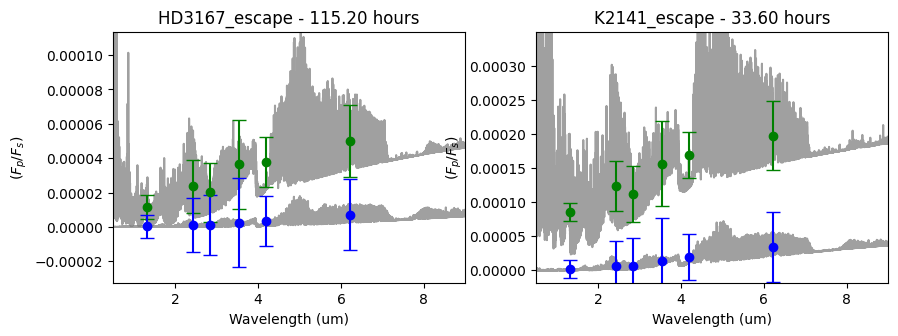

In [17]:
transits = 5

batch = 3  # 0: base names, 1: _1, 2: _10, 3: _escape 

print(f"Processing batch {batch}...")
fig = figure(figsize=(10,15))

for i, name in enumerate(planet_names):
    if batch == 0:
        name = name
    elif batch == 1:
        name = f"{name}_1"
    elif batch == 2:
        name = f"{name}_10"
    elif batch == 3:
        name = f"{name}_escape"
    else:
        print("Invalid batch selection.")
        continue

    base_name = name.split("_", 1)[0]

    result = save_eclipse(f"{name}", transits, False)
    if result is None:
        print(f"Skipping {name}")
        continue

    frame = fig.add_subplot(4, 2, i+1)
    output, noise, wlgrid, fpfs, output_t, wlgrid_t, fpfs_t = result

    frame.plot(wlgrid_t, fpfs_t, color='gray', alpha=.75)
    frame.plot(wlgrid, fpfs, color='gray', alpha=.75)

    # original binned points (red)
    #plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(transits), capsize=5, fmt='o', color='red')
    #plt.errorbar(output[0], output[1], yerr=noise/np.sqrt(transits), capsize=5, fmt='o', color='red', alpha=.25)

    results_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits, name,
                                new_point1, new_point2, new_point3, new_point4, 
                                new_point5, new_point6, new_point7, 
                                new_point8, new_point9, new_point10, 
                                new_point11, new_point12)

    results = bindown_multiple(output, noise, wlgrid, fpfs, transits, 
                                name, new_point1, new_point2, new_point3, 
                                new_point4, new_point5, new_point6, new_point7, 
                                new_point8, new_point9, new_point10, new_point11,
                                new_point12)
            
    new_points = make_next_level_points(results)
    new_points_t = make_next_level_points(results_t)

    results_level2 = bindown_multiple(output, noise, wlgrid, fpfs, transits, name, *new_points)
    results_level2_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits, name, *new_points_t)
        
    # new points (green)
    for out in results_level2:
        frame.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='green')

    for out in results_level2_t:
        frame.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='blue')

    frame.set_xlabel("Wavelength (um)")
    frame.set_ylabel("$(F_p/F_s)$")

    yerr = noise / np.sqrt(transits)

    # set appropriate y-limits based on the singular plot
    y_all = np.concatenate([
        output[1] + yerr,
        output[1] - yerr,
    ])

    ymin = y_all.min()
    ymax = y_all.max()

    pad = 0.0001 * (ymax - ymin)
    frame.set_ylim(ymin - pad, ymax + pad)

    time = float(planet_period[planet_names.index(base_name)]) * transits * 24 #in hours

    #plt.yscale("log")
    frame.set_xlim(0.5, 9)
    #plt.ylim(-0.00001,0.0003)
    frame.set_title(f"{name} - {time:.2f} hours")

    print(f"Finished plotting {name}.")

plt.tight_layout()
# plt.title(f"{transits} Eclipses")
savefig(f"plots/all_planets_{transits}_{batch}.pdf", format='pdf')
show()

## Spectrum Bin-down Functions

## MULTIPLE BINDOWNS

In [ ]:
# single plot
name = "TOI1807"
transits = 7
output, noise, wlgrid, fpfs, output_t, wlgrid_t, fpfs_t = save_eclipse(name, transits, plot=False)


In [ ]:
output[0], output[3]

In [ ]:
new_point1 = (0.95,0.3,1.156,0.112)
new_point2 = (1.549, 0.151, 1.708, 0.166)

new_point3 = (2.356, 0.0468, 2.403,0.0478)
new_point4 = (2.451, 0.0487, 2.500,0.0497)

new_point5 = (2.762,0.0549, 2.818, 0.056)
new_point6 = (2.875,0.057, 2.932, 0.058)

new_point7 = (3.439, 0.068, 3.507, 0.0690)
new_point8 = (3.578, 0.071, 3.65, 0.072)

new_point9 = (4.032, 0.264, 4.30, 0.282)

new_point11 = (5.597,0.367, 5.976, 0.391)
new_point12 = (6.38, 0.418, 6.814, 0.447)

In [ ]:
plt.figure(figsize=(8,6))

terminator = True


plt.plot(wlgrid_t, fpfs_t, color='gray', alpha=.75)
plt.plot(wlgrid, fpfs, color='gray', alpha=.75)

# original binned points (red)
#if terminator:
#plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(transits), capsize=5, fmt='o', color='red')
#plt.errorbar(output[0], output[1], yerr=noise/np.sqrt(transits), capsize=5, fmt='o', color='red', alpha=.25)

results_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits, name, new_point1, new_point2, new_point3, 
                           new_point4, new_point5, new_point6, new_point7, 
                           new_point8, new_point11,
                           new_point12)

results = bindown_multiple(output, noise, wlgrid, fpfs, transits, 
                           name, new_point1, new_point2, new_point3, 
                           new_point4, new_point5, new_point6, new_point7, 
                           new_point8, new_point11,
                           new_point12)
        
new_points = make_next_level_points(results); new_points_t = make_next_level_points(results_t)
new_points.append(new_point9); new_points_t.append(new_point9)

results_level2 = bindown_multiple(output, noise, wlgrid, fpfs, transits, name, *new_points)
results_level2_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits, name, *new_points_t)
    
# new points (green)
for out in results_level2:
    plt.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='red')
for out in results_level2_t:
    plt.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='blue')

plt.xlabel("Wavelength (um)")
plt.ylabel("$(F_p/F_s)$")

yerr = noise / np.sqrt(transits)

# set appropriate y-limits based on the singular plot
y_all = np.concatenate([
    output[1] + yerr,
    output[1] - yerr,
    output_t[1] + yerr,
    output_t[1] - yerr,
])

ymin = y_all.min()
ymax = y_all.max()

pad = 0.0001 * (ymax - ymin)
plt.ylim(ymin - pad, ymax + pad)

time = float(planet_period[planet_names.index(name)]) * transits * 24 #in hours

#plt.yscale("log")
plt.xlim(0.5, 9)
#plt.ylim(-0.00001,0.0003)
plt.tight_layout()
plt.title(f"{name} - {time:.2f} hours")
plt.savefig(f"{name}/{name}_{transits}.pdf", format='pdf')
plt.show()

# Dayside vs Nightside

In [ ]:
transits = 10

fig = figure(figsize=(12, 20))

for name in planet_names:
    result = save_eclipse(name, transits, plot=False)
    if result is None:
        print(f"Skipping {name}")
        continue
    output, noise, wlgrid, fpfs, output_t, wlgrid_t, fpfs_t = result

    results = bindown_multiple(output, noise, wlgrid, fpfs, transits, 
                                   name, new_point1, new_point2, new_point3, 
                                   new_point4, new_point5, new_point6, new_point7, 
                                   new_point8, new_point9, new_point10, new_point11,
                                   new_point12)
    
    results_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits,
                                   name, new_point1, new_point2, new_point3,
                                   new_point4, new_point5, new_point6, new_point7,
                                   new_point8, new_point9, new_point10, new_point11,
                                   new_point12)
    
    frame = fig.add_subplot(4, 2, planet_names.index(name)+1)
    frame.set_xlabel("Wavelength (um)")
    frame.set_ylabel("$(F_p/F_s)$")
    frame.set_xlim(0.5, 8)
    #frame.set_ylim(-0.00001,0.0003)

    yerr = noise / np.sqrt(transits)

    # set appropriate y-limits based on the singular plot
    y_all = np.concatenate([
        output[1] + yerr,
        output[1] - yerr,
        output_t[1] + yerr,
        output_t[1] - yerr,
    ])

    ymin = y_all.min()
    ymax = y_all.max()

    pad = 0.00001 * (ymax - ymin)
    frame.set_ylim(ymin - pad, ymax + pad)

    time = float(planet_period[planet_names.index(name)]) * transits * 24 #in hours
    frame.set_title(f"{name} - {time:.2f} hours")

    frame.plot(wlgrid, fpfs, color='gray',alpha=.5, label='Dayside Profile')
    frame.plot(wlgrid_t, fpfs_t, color='gray', alpha=.5, label='Nightside Profile')

    new_points = make_next_level_points(results)
    results_level2 = bindown_multiple(output, noise, wlgrid, fpfs, transits, name, *new_points)

    new_points_t = make_next_level_points(results_t)
    results_level2_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits, name, *new_points_t)

    for out in results_level2:
        plt.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='red')

    for out in results_level2_t:
        plt.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='blue')

    #frame.legend()
    plt.savefig(f"{name}/{name}-dayside-nightside-spectrum.pdf", format='pdf')

plt.tight_layout()
plt.savefig(f"dayside-nightside-{transits}.pdf", format='pdf')
show()



In [ ]:
plt.figure(figsize=(8,6))
plt.xlabel("Wavelength (um)")
plt.ylabel("$(F_p/F_s)$")
#plt.yscale("log")
plt.xlim(0.5, 8)
plt.plot(wlgrid, fpfs, color='black',alpha=0.3)
plt.plot(wlgrid_t, fpfs_t, color='black',alpha=0.3)

plt.errorbar(output[0], output[1], yerr=noise/np.sqrt(transits), fmt='o',capsize=5, color='red', label='Dayside Spectrum')
plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(transits), fmt='o',capsize=5, color='blue', label='Nightside Spectrum')
plt.legend()
plt.ylim(-0.00001,0.0001)
plt.tight_layout()
plt.title(f"{name} - Dayside/Nightside Spectrum {transits} Transits")
plt.savefig(f"{name}/{name}-dayside-nightside-spectrum.pdf", format='pdf')
plt.show()